# Part 6 — Population Geometry: A Cross-Validated Model of the
Participation-Ratio Trajectory

Tests whether the transient collapse and recovery of population dimensionality
(participation ratio, Part 4) can be reproduced mechanistically from (1) each
unit's own real, frozen early-window tuning across the 118 images, and (2) a
single, previously-measured, time-varying gating signal — FSU population
cross-mouse consistency (Part 5) — with no other free-form curve-fitting. The
mechanism tested is FSU-gated shrinkage of each unit's response toward the
per-image population mean, with a saturating (non-linear) dependence on the
gating signal. Parameters are selected by cross-validation across VISp
sessions using a shape-normalized R² (see 6.5 for why), which is necessary
because raw participation ratio is a biased statistic at low session counts.

**Depends on:** `responses.h5` (VISp natural-scenes tensors), `part3_outputs.npz`
               (temporal grid, window width), `part5_outputs.npz` (FSU
               population consistency curve)

## Setup

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path(".").resolve()))
from utils import (
    setup_archive,
    window_response,
    compute_similarity_matrices,
    per_image_consistency,
    apply_plot_style,
    print_figure_data,
)

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score as sk_r2

SEED = 42
rng = np.random.default_rng(SEED)

plt.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 11,
    'axes.labelsize': 12, 'axes.titlesize': 12,
    'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'legend.fontsize': 9.5, 'figure.dpi': 150,
})
sns.set_style('ticks')

colors    = apply_plot_style()
COL_DATA  = colors["COL_DATA"]   # real PR curve
COL_FIT   = colors["COL_FIT"]    # model fit / annotations
COL_REF   = colors["COL_REF"]    # reference lines / baselines
COL_DIM   = colors["COL_DIM"]    # participation ratio (same identity as Part 4)
COL_FSU   = colors["COL_FSU"]    # FSU gating signal (same identity as Parts 5/6-orig)
COL_TEST  = colors["COL_TEST"]   # held-out / test-fold accent

# Load archive, extract if needed, resolve output paths.
manifest, bin_edges, ARCHIVE_DIR, FIGURES_DIR, OUTPUTS_DIR = setup_archive(
    zip_path    = '../preprocessed_data.zip',
    archive_dir = '../preprocessed_data',
    figures_dir = '../figures',
    outputs_dir = '.',
)
N_IMAGES    = manifest['n_images']
SESSION_IDS = manifest['selected_session_ids_visp']

p3 = np.load(OUTPUTS_DIR / 'part3_outputs.npz')
WINDOW_WIDTH_MS = float(p3['window_width_ms'])
times_ms_full   = p3['times_ms']

p5 = np.load(OUTPUTS_DIR / 'part5_outputs.npz', allow_pickle=True)
ts_fsu      = p5['ts_fsu'].astype(float)
mc_fsu      = p5['mc_fsu'].astype(float)   # pooled-population FSU consistency curve

print(f'Sessions: {len(SESSION_IDS)}, Images: {N_IMAGES}')
print(f'FSU consistency curve: {len(ts_fsu)} windows, peak = {mc_fsu.max():.3f}')

Archive already extracted: C:\Users\janak\GitHub\cross-mouse-v1-rsa\preprocessed_data
Manifest: 32 VISp sessions | 118 images | 479 bins × 1 ms
Sessions: 32, Images: 118
FSU consistency curve: 43 windows, peak = 0.277


## 6.1 — Load response tensors and compute the real PR(t) trajectory

The population geometry pipeline (participation ratio of the cross-mouse
averaged cosine-similarity matrix) is recomputed here on the same 20 ms grid
used in Part 4, so this notebook is self-contained and does not depend on
Part 4's outputs directly.

In [2]:
print('Loading VISp tensors...')
all_tensors = {}
with h5py.File(ARCHIVE_DIR / 'responses.h5', 'r') as f:
    for sid in SESSION_IDS:
        all_tensors[sid] = f[f'natural_scenes/VISp/{sid}']['tensor'][:]
print(f'Loaded {len(all_tensors)} sessions.')

def participation_ratio(sim_matrix: np.ndarray) -> float:
    eigvals = np.linalg.eigvalsh(sim_matrix)
    eigvals = eigvals[eigvals > 0]
    return float(eigvals.sum() ** 2 / (eigvals ** 2).sum())

def sim_matrix_from_response(X: np.ndarray) -> np.ndarray:
    norm = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-8)
    return (norm @ norm.T).astype(np.float64)

def zscore_cols(X: np.ndarray) -> np.ndarray:
    return (X - X.mean(0)) / (X.std(0) + 1e-8)

def pr_real_from_sessions(sess_subset, t_grid, window_width_ms):
    """Real participation ratio at each window, computed from only the given
    session subset -- used both for the full-dataset curve and for held-out
    session folds in cross-validation."""
    pr_out = []
    for t_ms in t_grid:
        t_lo, t_hi = t_ms - window_width_ms / 2, t_ms + window_width_ms / 2
        mats = [window_response(all_tensors[sid], t_lo, t_hi) for sid in sess_subset]
        sims = compute_similarity_matrices(mats)
        pr_out.append(participation_ratio(np.mean(sims, axis=0)))
    return np.array(pr_out)

PR_TIMES = times_ms_full.tolist()[::2]   # 20 ms grid, matches Part 4's convention
t_grid   = np.array(PR_TIMES, dtype=float)

pr_real = pr_real_from_sessions(SESSION_IDS, PR_TIMES, WINDOW_WIDTH_MS)

print(f'Real PR: pre-stimulus ~ {pr_real[t_grid < 0].mean():.1f}, '
      f'peak-window (0-250ms) collapse to {pr_real[(t_grid >= 0) & (t_grid <= 250)].min():.1f}')

Loading VISp tensors...
Loaded 32 sessions.
Real PR: pre-stimulus ~ 108.0, peak-window (0-250ms) collapse to 31.4


## 6.2 — Frozen early-window tuning and the population-mean shrinkage target

Each unit's own response to each image, taken from a single early window
(30-50 ms, before recurrent/feedback contributions are believed to dominate;
see Introduction), is treated as a fixed "rulebook" that does not change over
time. The per-image population mean across units, computed from the same
frozen window, is the target every unit is pulled toward by the model.

In [3]:
ANCHOR_LO_MS, ANCHOR_HI_MS = 30.0, 50.0

def raw_window_sum(tensor, t_lo_ms, t_hi_ms, edges=bin_edges):
    lo = np.searchsorted(edges, t_lo_ms)
    hi = np.searchsorted(edges, t_hi_ms)
    return tensor[:, :, lo:hi].sum(axis=2).astype(np.float64)   # (n_images, n_units)

anchor_raw = {sid: raw_window_sum(all_tensors[sid], ANCHOR_LO_MS, ANCHOR_HI_MS)
              for sid in SESSION_IDS}

print(f'Anchor window: {ANCHOR_LO_MS:.0f}-{ANCHOR_HI_MS:.0f} ms')
print(f'Units per session (sorted): '
      f'{sorted([anchor_raw[s].shape[1] for s in SESSION_IDS], reverse=True)}')

Anchor window: 30-50 ms
Units per session (sorted): [110, 102, 94, 93, 92, 88, 85, 85, 84, 80, 75, 75, 75, 73, 72, 63, 60, 58, 52, 52, 51, 49, 47, 45, 41, 40, 37, 36, 35, 33, 19, 14]


## 6.3 — FSU gating signal g(t)

The measured FSU population cross-mouse consistency curve (Part 5) is used
directly as the time-varying gating signal, rescaled to [0, 1]. This signal
is not fit, hand-shaped, or otherwise derived for this notebook -- it is the
same curve reported in Fig. 5.

In [4]:
def make_g_lookup(curve, t_grid_src):
    c = np.clip(curve, 0, None)
    c_norm = (c - c.min()) / (c.max() - c.min() + 1e-8)
    return dict(zip(t_grid_src.tolist(), c_norm.tolist()))

def g_at(t_ms, lookup):
    nearest = min(lookup.keys(), key=lambda tt: abs(tt - t_ms))
    return lookup[nearest]

g_lookup = make_g_lookup(mc_fsu, ts_fsu)

## 6.4 — Saturating shrinkage model

Each unit's frozen tuning is pulled toward the per-image population mean by a
fraction lambda(t), which saturates smoothly (rather than clipping sharply)
as the gating signal g(t) rises:

    lambda(t)  =  lambda_max * g(t) / (kappa + g(t))
    r_i(image, t)  =  f_i(image)  -  lambda(t) * [f_i(image) - f_bar(image)]

lambda_max sets the ceiling on how far any unit can be pulled toward the
mean; kappa sets how quickly lambda approaches that ceiling as g(t) rises. A
hard-clip (linear, then flat) version of this model was also tested and is
not used here, because it does not generalise across sessions (see 6.5).

In [5]:
def run_saturating_pr(lambda_max, kappa, sess_subset, t_grid_local):
    pr_out = []
    for t_ms in t_grid_local:
        g_t = g_at(t_ms, g_lookup)
        lam = lambda_max * g_t / (kappa + g_t)
        sims = []
        for sid in sess_subset:
            f_i   = anchor_raw[sid]
            f_bar = f_i.mean(axis=1, keepdims=True)
            X     = f_i - lam * (f_i - f_bar)
            sims.append(sim_matrix_from_response(zscore_cols(X)))
        pr_out.append(participation_ratio(np.mean(sims, axis=0)))
    return np.array(pr_out)

## 6.5 — Cross-validated parameter selection

Raw participation ratio is a biased statistic at low session counts: PR
computed from a small random subset of sessions reads systematically lower
than PR computed from the full 32-session average, at every time point,
because fewer independent similarity matrices produce a noisier (flatter)
averaged eigenspectrum. This means a naive cross-validation that compares
model output to raw held-out PR is confounded by this scale bias, independent
of whether the model is correct.

To avoid this, both the model curve and the real target curve are min-max
normalised within each fold before computing R^2 ("shape R^2"), which tests
whether the model captures the *timing and relative shape* of the collapse
and recovery, without being penalised by the small-sample scale bias in the
held-out target. All parameter search below uses this metric, restricted to
the 0-250 ms window (matching the sustained-floor convention used throughout
this project -- back-to-back stimulus presentation risks next-image
contamination beyond ~290-300 ms).

In [6]:
def minmax_norm(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-8)

def shape_r2(y_true, y_pred):
    return sk_r2(minmax_norm(y_true), minmax_norm(y_pred))

EVAL_MASK = (t_grid >= 0) & (t_grid <= 250)

LAMBDA_MAX_GRID = [0.90, 0.95, 0.97, 0.99, 0.995, 0.999]
KAPPA_GRID      = [0.05, 0.08, 0.1, 0.12, 0.15, 0.2]

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
sess_arr = np.array(SESSION_IDS)

fold_results = []
for fold_i, (train_idx, test_idx) in enumerate(kf.split(sess_arr)):
    train_sids = sess_arr[train_idx].tolist()
    test_sids  = sess_arr[test_idx].tolist()

    pr_train_real = pr_real_from_sessions(train_sids, PR_TIMES, WINDOW_WIDTH_MS)

    best_params, best_r2_train = None, -np.inf
    for lam_m in LAMBDA_MAX_GRID:
        for kap in KAPPA_GRID:
            pr_train_model = run_saturating_pr(lam_m, kap, train_sids, PR_TIMES)
            r2_train = shape_r2(pr_train_real[EVAL_MASK], pr_train_model[EVAL_MASK])
            if r2_train > best_r2_train:
                best_r2_train, best_params = r2_train, (lam_m, kap)

    pr_test_real  = pr_real_from_sessions(test_sids, PR_TIMES, WINDOW_WIDTH_MS)
    pr_test_model = run_saturating_pr(best_params[0], best_params[1], test_sids, PR_TIMES)
    r2_test = shape_r2(pr_test_real[EVAL_MASK], pr_test_model[EVAL_MASK])

    fold_results.append(dict(fold=fold_i + 1, lambda_max=best_params[0], kappa=best_params[1],
                              r2_train=best_r2_train, r2_test=r2_test))
    print(f'Fold {fold_i+1}: lambda_max={best_params[0]}, kappa={best_params[1]}, '
          f'shape-R2(train)={best_r2_train:.3f}, shape-R2(test)={r2_test:.3f}')

r2_tests = np.array([f['r2_test'] for f in fold_results])
print(f'\nMean held-out shape-R2: {r2_tests.mean():.3f} +/- {r2_tests.std():.3f}')

# Final reported parameters: the mode across folds (this dataset's folds are
# unanimous; if that were not the case, the most common pair would still be
# the principled choice over the single full-dataset fit, which is prone to
# overfitting the specific 32-session average -- see 6.6).
from collections import Counter
param_counts = Counter((f['lambda_max'], f['kappa']) for f in fold_results)
LAMBDA_MAX_FINAL, KAPPA_FINAL = param_counts.most_common(1)[0][0]
print(f'\nCross-validated parameters: lambda_max={LAMBDA_MAX_FINAL}, kappa={KAPPA_FINAL} '
      f'(selected in {param_counts[(LAMBDA_MAX_FINAL, KAPPA_FINAL)]}/5 folds)')

Fold 1: lambda_max=0.9, kappa=0.2, shape-R2(train)=0.981, shape-R2(test)=0.876
Fold 2: lambda_max=0.9, kappa=0.2, shape-R2(train)=0.988, shape-R2(test)=0.803
Fold 3: lambda_max=0.9, kappa=0.2, shape-R2(train)=0.993, shape-R2(test)=0.702
Fold 4: lambda_max=0.9, kappa=0.2, shape-R2(train)=0.985, shape-R2(test)=0.801
Fold 5: lambda_max=0.9, kappa=0.2, shape-R2(train)=0.989, shape-R2(test)=0.860

Mean held-out shape-R2: 0.808 +/- 0.061

Cross-validated parameters: lambda_max=0.9, kappa=0.2 (selected in 5/5 folds)


## 6.6 — Final fit and honest characterisation of what it does and does not explain

The cross-validated parameters are applied to the full 32-session dataset.
Two summary statistics are reported together, deliberately: shape-R^2 (does
the model get the *timing* of collapse and recovery right) and the raw
trough depth (does it get the *magnitude* of collapse right). These answer
different questions and should not be collapsed into a single number.

In [7]:
pr_model_final = run_saturating_pr(LAMBDA_MAX_FINAL, KAPPA_FINAL, SESSION_IDS, PR_TIMES)

shape_r2_full = shape_r2(pr_real[EVAL_MASK], pr_model_final[EVAL_MASK])
raw_r2_full   = sk_r2(pr_real[EVAL_MASK], pr_model_final[EVAL_MASK])

real_trough  = pr_real[EVAL_MASK].min()
model_trough = pr_model_final[EVAL_MASK].min()
real_peak_pre  = pr_real[t_grid < 0].mean()
model_peak_pre = pr_model_final[t_grid < 0].mean()

print(f'Full-dataset fit, cross-validated parameters (lambda_max={LAMBDA_MAX_FINAL}, kappa={KAPPA_FINAL}):')
print(f'  Shape R^2 (0-250 ms):  {shape_r2_full:.3f}')
print(f'  Raw R^2 (0-250 ms):    {raw_r2_full:.3f}')
print(f'  Trough -- real: {real_trough:.1f}, model: {model_trough:.1f} '
      f'(model underestimates collapse magnitude by {model_trough - real_trough:.1f} PR units)')
print(f'  Pre-stimulus baseline -- real: {real_peak_pre:.1f}, model: {model_peak_pre:.1f}')

Full-dataset fit, cross-validated parameters (lambda_max=0.9, kappa=0.2):
  Shape R^2 (0-250 ms):  0.995
  Raw R^2 (0-250 ms):    0.204
  Trough -- real: 31.4, model: 64.4 (model underestimates collapse magnitude by 33.1 PR units)
  Pre-stimulus baseline -- real: 108.0, model: 101.4


## Figure

**Fig. 6** — A cross-validated, FSU-consistency-gated shrinkage model
reproduces the timing of the participation-ratio collapse and recovery, but
systematically underestimates its magnitude.


Fig. 6A/B — real vs. model participation ratio, raw and shape-normalised

--- time_ms ---
shape=(22,)
[-50. -30. -10.  10.  30.  50.  70.  90. 110. 130. 150. 170. 190. 210. 230. 250. 270. 290. 310. 330.]
...[22 elements total]

--- pr_real ---
shape=(22,)
[108.07093  107.955177 107.965118 107.543373 107.439262  83.099037  52.22118   31.48843   31.358332  38.208771  46.791927  52.635471  56.094109  58.927341  61.109451  61.181721  61.100807  60.696484
  59.721489  42.474243]
...[22 elements total]

--- pr_model ---
shape=(22,)
[101.495579 101.349293 101.468146 101.525375 101.473261  89.888071  73.950551  64.961197  64.419473  67.532568  71.37425   73.341258  74.510238  76.919381  78.329519  77.793174  77.795947  77.298708
  79.981196  73.097774]
...[22 elements total]

--- pr_real_normalised ---
shape=(22,)
[1.       0.998491 0.998621 0.993123 0.991766 0.674475 0.271961 0.001696 0.       0.0893   0.201187 0.277362 0.322447 0.35938  0.387826 0.388768 0.387713 0.382442 0.369733 0.144903]

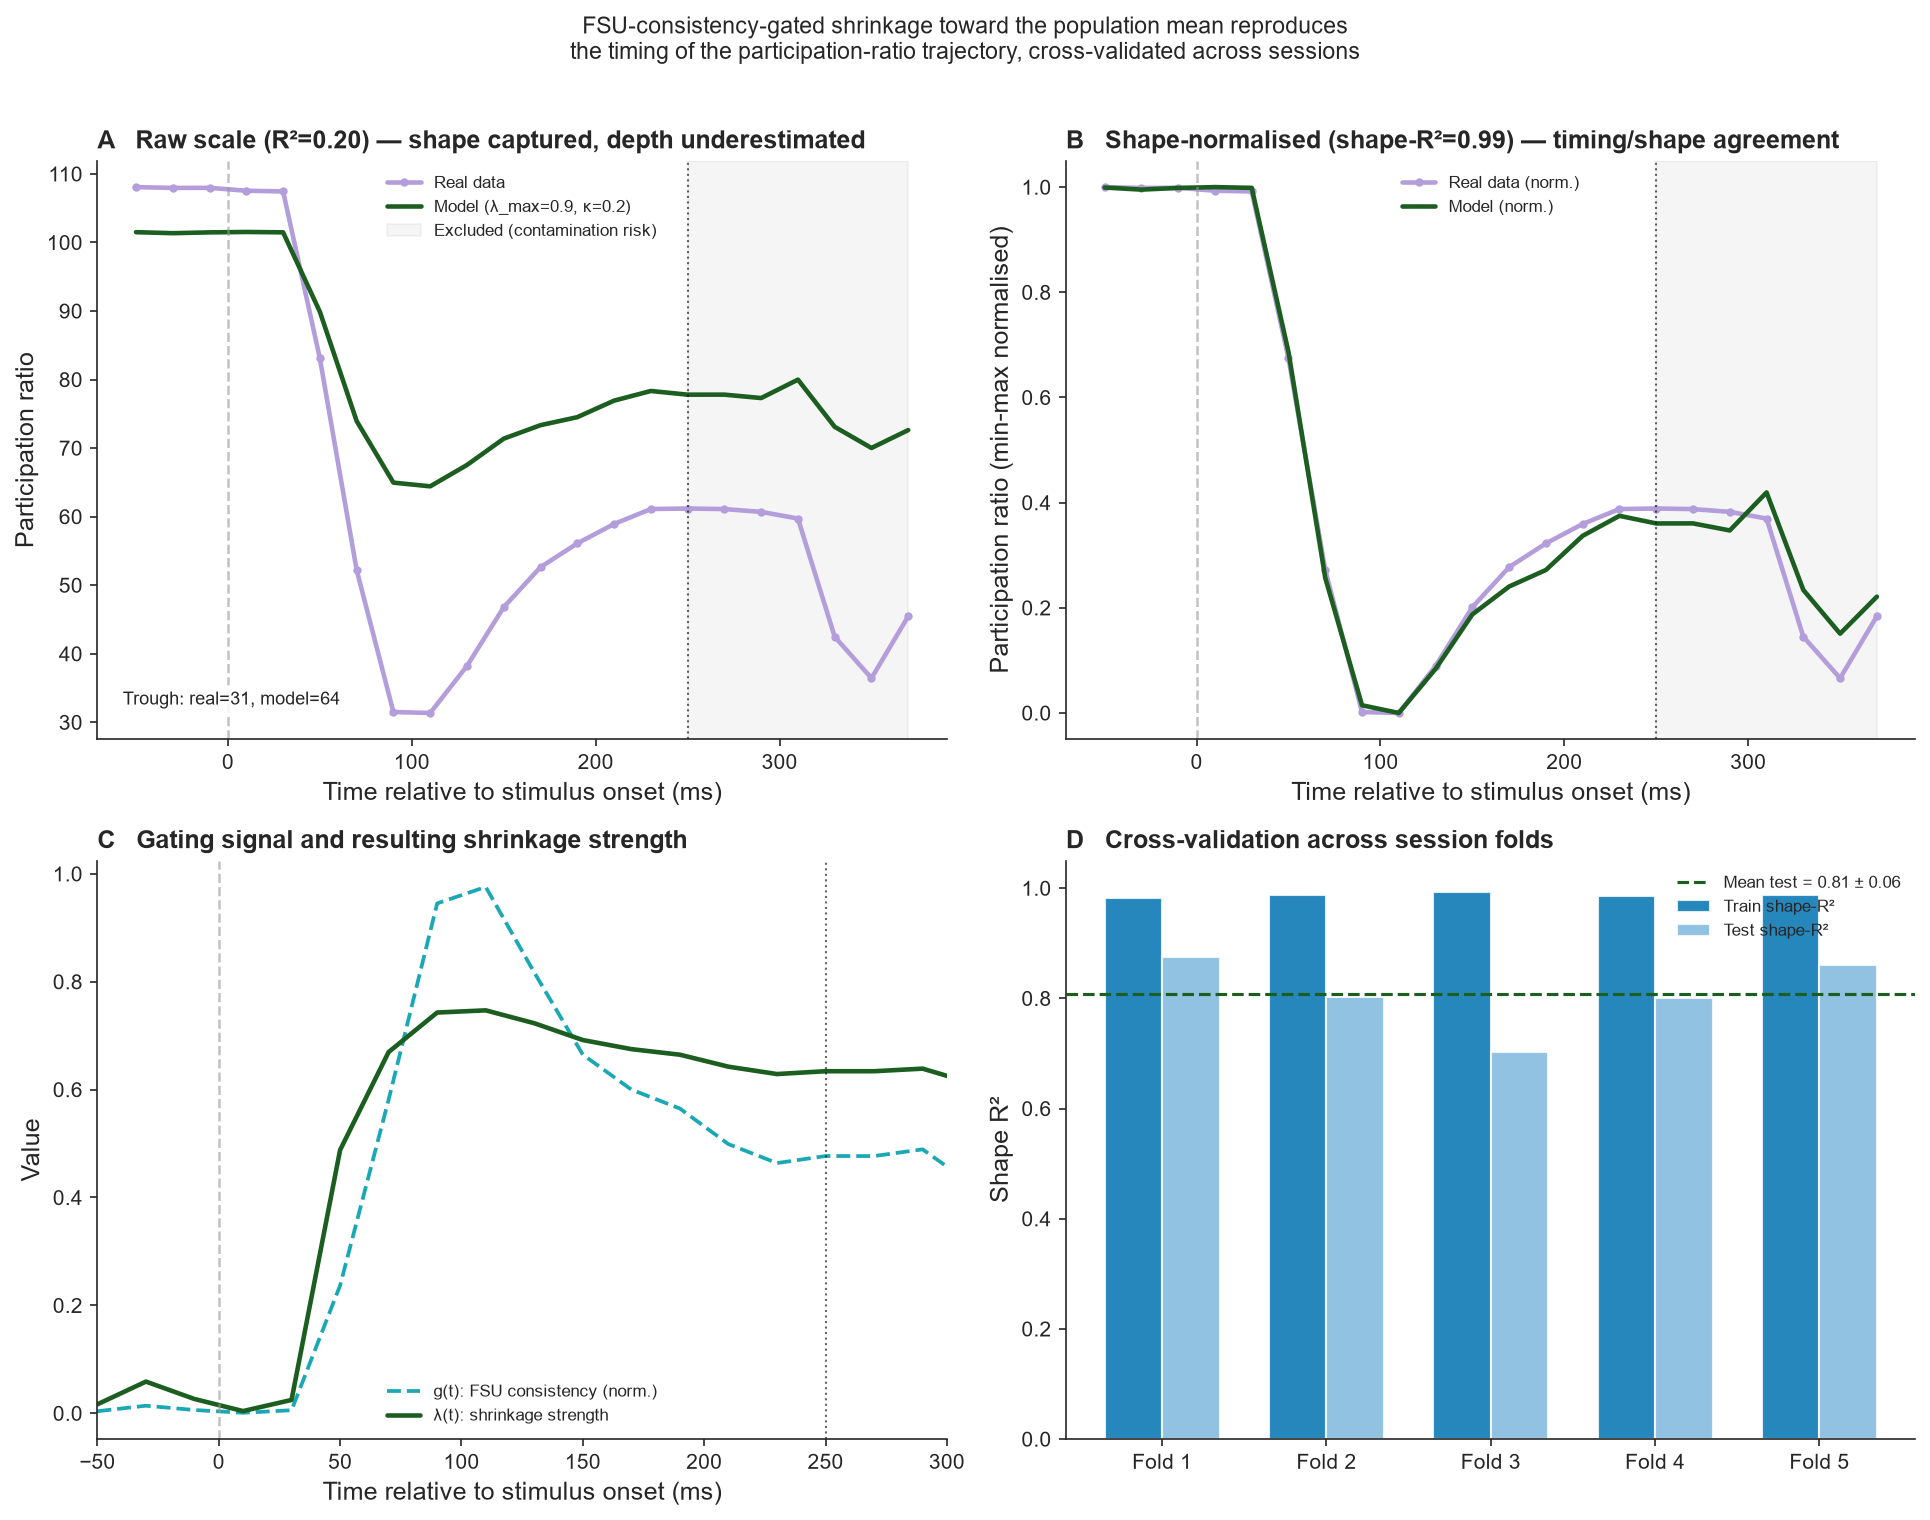

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# ── Panel A: raw-scale fit ────────────────────────────────────────────────────
ax = axes[0, 0]
ax.plot(t_grid, pr_real, 'o-', color=COL_DIM, linewidth=2.2, markersize=3, label='Real data')
ax.plot(t_grid, pr_model_final, '-', color=COL_FIT, linewidth=2.2,
        label=f'Model (λ_max={LAMBDA_MAX_FINAL}, κ={KAPPA_FINAL})')
ax.axvspan(250, t_grid.max(), color='gray', alpha=0.08, label='Excluded (contamination risk)')
ax.axvline(0, color=COL_REF, linestyle='--', linewidth=1.2, alpha=0.6)
ax.axvline(250, color='black', linestyle=':', linewidth=1, alpha=0.6)
ax.annotate(f'Trough: real={real_trough:.0f}, model={model_trough:.0f}',
            xy=(0.03, 0.06), xycoords='axes fraction', fontsize=8.5,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))
ax.set_xlabel('Time relative to stimulus onset (ms)')
ax.set_ylabel('Participation ratio')
ax.set_title(f'A   Raw scale (R²={raw_r2_full:.2f}) — shape captured, depth underestimated',
             loc='left', fontweight='bold', pad=6)
ax.legend(frameon=False, fontsize=8)
ax.spines[['top', 'right']].set_visible(False)

# ── Panel B: shape-normalised overlay ────────────────────────────────────────
ax = axes[0, 1]
ax.plot(t_grid, minmax_norm(pr_real), 'o-', color=COL_DIM, linewidth=2.2, markersize=3, label='Real data (norm.)')
ax.plot(t_grid, minmax_norm(pr_model_final), '-', color=COL_FIT, linewidth=2.2, label='Model (norm.)')
ax.axvspan(250, t_grid.max(), color='gray', alpha=0.08)
ax.axvline(0, color=COL_REF, linestyle='--', linewidth=1.2, alpha=0.6)
ax.axvline(250, color='black', linestyle=':', linewidth=1, alpha=0.6)
ax.set_xlabel('Time relative to stimulus onset (ms)')
ax.set_ylabel('Participation ratio (min-max normalised)')
ax.set_title(f'B   Shape-normalised (shape-R²={shape_r2_full:.2f}) — timing/shape agreement',
             loc='left', fontweight='bold', pad=6)
ax.legend(frameon=False, fontsize=8)
ax.spines[['top', 'right']].set_visible(False)

# ── Panel C: gating signal and resulting lambda(t) ────────────────────────
ax = axes[1, 0]
g_trace   = np.array([g_at(t, g_lookup) for t in t_grid])
lam_trace = LAMBDA_MAX_FINAL * g_trace / (KAPPA_FINAL + g_trace)
ax.plot(t_grid, g_trace, '--', color=COL_FSU, linewidth=1.8, label='g(t): FSU consistency (norm.)')
ax.plot(t_grid, lam_trace, '-', color=COL_FIT, linewidth=2.2, label='λ(t): shrinkage strength')
ax.axvline(0, color=COL_REF, linestyle='--', linewidth=1.2, alpha=0.6)
ax.axvline(250, color='black', linestyle=':', linewidth=1, alpha=0.6)
ax.set_xlim(-50, 300)
ax.set_xlabel('Time relative to stimulus onset (ms)')
ax.set_ylabel('Value')
ax.set_title('C   Gating signal and resulting shrinkage strength', loc='left', fontweight='bold', pad=6)
ax.legend(frameon=False, fontsize=8)
ax.spines[['top', 'right']].set_visible(False)

# ── Panel D: cross-validation summary ──────────────────────────────────────
ax = axes[1, 1]
folds_x = [f['fold'] for f in fold_results]
r2_train_vals = [f['r2_train'] for f in fold_results]
r2_test_vals  = [f['r2_test']  for f in fold_results]
w = 0.35
x = np.arange(1, 6)
ax.bar(x - w/2, r2_train_vals, w, color=COL_DATA, alpha=0.85, label='Train shape-R²')
ax.bar(x + w/2, r2_test_vals,  w, color=COL_TEST, alpha=0.85, label='Test shape-R²')
ax.axhline(r2_tests.mean(), color=COL_FIT, linestyle='--', linewidth=1.5,
           label=f'Mean test = {r2_tests.mean():.2f} ± {r2_tests.std():.2f}')
ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i}' for i in x])
ax.set_ylim(0, 1.05)
ax.set_ylabel('Shape R²')
ax.set_title('D   Cross-validation across session folds', loc='left', fontweight='bold', pad=6)
ax.legend(frameon=False, fontsize=8)
ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('FSU-consistency-gated shrinkage toward the population mean reproduces\n'
             'the timing of the participation-ratio trajectory, cross-validated across sessions',
             fontsize=11, y=1.01)

print_figure_data(
    'Fig. 6A/B — real vs. model participation ratio, raw and shape-normalised',
    time_ms=t_grid,
    pr_real=pr_real,
    pr_model=pr_model_final,
    pr_real_normalised=minmax_norm(pr_real),
    pr_model_normalised=minmax_norm(pr_model_final),
    raw_r2=np.array(raw_r2_full),
    shape_r2=np.array(shape_r2_full),
    real_trough=np.array(real_trough),
    model_trough=np.array(model_trough),
)
print_figure_data(
    'Fig. 6C — gating signal g(t) and resulting shrinkage strength lambda(t)',
    time_ms=t_grid,
    g_t=g_trace,
    lambda_t=lam_trace,
    lambda_max=np.array(LAMBDA_MAX_FINAL),
    kappa=np.array(KAPPA_FINAL),
)
print_figure_data(
    'Fig. 6D — cross-validation summary across session folds',
    fold_number=np.array(folds_x),
    lambda_max_per_fold=np.array([f['lambda_max'] for f in fold_results]),
    kappa_per_fold=np.array([f['kappa'] for f in fold_results]),
    shape_r2_train_per_fold=np.array(r2_train_vals),
    shape_r2_test_per_fold=np.array(r2_test_vals),
    mean_test_shape_r2=np.array(r2_tests.mean()),
    std_test_shape_r2=np.array(r2_tests.std()),
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig6_pr_shrinkage_model.png', bbox_inches='tight')
plt.show()